In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing

np.random.seed(10)

In [77]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [78]:
features = ["MedInc", "HouseAge"]
target = "MedHouseVal"

X = df[features].values.astype(np.float64)
y = df[target].values.reshape(-1, 1).astype(np.float64)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20640, 2)
y shape: (20640, 1)


## 3. 80/20 Train-Test Split

In [79]:
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 16512
Test samples: 4128


In [80]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

print("Training mean:", X_train_norm.mean(axis=0))
print("Training std:", X_train_norm.std(axis=0))


Training mean: [-6.68615545e-15  1.20233819e-16]
Training std: [1. 1.]


In [81]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


## 6. Neural Network From Scratch

Required architecture:

`2 → 5 → 3 → 1`

The same class is also used for the bonus architecture:

`2 → 5 → 3 → 2 → 1`


In [82]:
class NeuralNetwork:
    def __init__(self, layer_sizes, seed=10):
        rng = np.random.default_rng(seed)

        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.weights = []
        self.biases = []

        for i in range(self.num_layers):
            fan_in = layer_sizes[i]

            W = rng.normal(
                0,
                np.sqrt(2.0 / fan_in),
                size=(layer_sizes[i], layer_sizes[i + 1])
            )
            b = np.zeros((1, layer_sizes[i + 1]))

            self.weights.append(W)
            self.biases.append(b)

    def forward(self, X):
        A = X
        activations = [X]
        pre_activations = []

        for i in range(self.num_layers):
            Z = A @ self.weights[i] + self.biases[i]
            pre_activations.append(Z)

            if i < self.num_layers - 1:
                A = relu(Z)
            else:
                A = Z

            activations.append(A)

        return A, activations, pre_activations

    def predict(self, X):
        return self.forward(X)[0]


## 7. Backpropagation

In [83]:
def loss_and_gradients(model, X, y, l2=0.0):
    n = X.shape[0]

    y_pred, activations, pre_activations = model.forward(X)

    data_loss = np.mean((y_pred - y) ** 2)

    reg_loss = 0.5 * l2 * sum(
        np.sum(W ** 2) for W in model.weights
    )

    loss = data_loss + reg_loss

    dW = [None] * model.num_layers
    db = [None] * model.num_layers

    dA = 2 * (y_pred - y) / n

    for i in reversed(range(model.num_layers)):

        if i < model.num_layers - 1:
            dZ = dA * relu_derivative(pre_activations[i])
        else:
            dZ = dA

        dW[i] = activations[i].T @ dZ
        db[i] = np.sum(dZ, axis=0, keepdims=True)

        if l2 > 0:
            dW[i] += l2 * model.weights[i]

        if i > 0:
            dA = dZ @ model.weights[i].T

    return loss, dW, db


In [84]:
def create_optimizer_state(model, optimizer):
    state = {}

    if optimizer == "momentum":
        state["vW"] = [np.zeros_like(W) for W in model.weights]
        state["vb"] = [np.zeros_like(b) for b in model.biases]

    elif optimizer == "adam":
        state["mW"] = [np.zeros_like(W) for W in model.weights]
        state["mb"] = [np.zeros_like(b) for b in model.biases]
        state["vW"] = [np.zeros_like(W) for W in model.weights]
        state["vb"] = [np.zeros_like(b) for b in model.biases]
        state["t"] = 0

    return state


In [85]:
def update_parameters(
    model,
    dW,
    db,
    optimizer,
    lr,
    state,
    momentum_beta=0.9,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
):
    if optimizer == "gd":

        for i in range(model.num_layers):
            model.weights[i] -= lr * dW[i]
            model.biases[i] -= lr * db[i]

    elif optimizer == "momentum":

        for i in range(model.num_layers):
            state["vW"][i] = (
                momentum_beta * state["vW"][i] + dW[i]
            )
            state["vb"][i] = (
                momentum_beta * state["vb"][i] + db[i]
            )

            model.weights[i] -= lr * state["vW"][i]
            model.biases[i] -= lr * state["vb"][i]

    elif optimizer == "adam":

        state["t"] += 1
        t = state["t"]

        for i in range(model.num_layers):
            state["mW"][i] = (
                beta1 * state["mW"][i]
                + (1 - beta1) * dW[i]
            )
            state["mb"][i] = (
                beta1 * state["mb"][i]
                + (1 - beta1) * db[i]
            )

            state["vW"][i] = (
                beta2 * state["vW"][i]
                + (1 - beta2) * dW[i] ** 2
            )
            state["vb"][i] = (
                beta2 * state["vb"][i]
                + (1 - beta2) * db[i] ** 2
            )

            mW_hat = state["mW"][i] / (1 - beta1 ** t)
            mb_hat = state["mb"][i] / (1 - beta1 ** t)

            vW_hat = state["vW"][i] / (1 - beta2 ** t)
            vb_hat = state["vb"][i] / (1 - beta2 ** t)

            model.weights[i] -= (
                lr * mW_hat / (np.sqrt(vW_hat) + epsilon)
            )
            model.biases[i] -= (
                lr * mb_hat / (np.sqrt(vb_hat) + epsilon)
            )

    else:
        raise ValueError("Unknown optimizer")


In [86]:
def train_network(
    layer_sizes,
    X_train,
    y_train,
    optimizer,
    lr,
    epochs=5000,
    l2=0.0,
    seed=10
):
    model = NeuralNetwork(layer_sizes, seed)
    state = create_optimizer_state(model, optimizer)

    history = []
    start_time = time.time()

    for epoch in range(epochs):

        loss, dW, db = loss_and_gradients(
            model,
            X_train,
            y_train,
            l2=l2
        )

        if not np.isfinite(loss):
            print("Training diverged at epoch:", epoch)
            break

        history.append(loss)

        update_parameters(
            model,
            dW,
            db,
            optimizer,
            lr,
            state
        )

    elapsed = time.time() - start_time

    return model, history, elapsed


def evaluate_model(model, X, y):
    predictions = model.predict(X)

    test_mse = np.mean((y - predictions) ** 2)
    test_rmse = np.sqrt(test_mse)

    return test_mse, test_rmse, predictions


In [87]:
architecture = [2, 5, 3, 1]

optimizers = {
    "Gradient Descent": "gd",
    "Momentum": "momentum",
    "Adam": "adam"
}

learning_rates = [0.01, 0.001]
epochs = 5000

results = []
trained_models = {}

for name, optimizer_code in optimizers.items():

    for lr in learning_rates:

        print(f"Training {name}, learning rate = {lr}")

        model, history, elapsed = train_network(
            architecture,
            X_train_norm,
            y_train,
            optimizer=optimizer_code,
            lr=lr,
            epochs=epochs,
            l2=0.0,
            seed=10
        )

        test_mse, test_rmse, predictions = evaluate_model(
            model,
            X_test_norm,
            y_test
        )

        results.append({
            "Optimizer": name,
            "Learning Rate": lr,
            "Final Training Loss": history[-1],
            "Test MSE": test_mse,
            "Test RMSE": test_rmse,
            "Training Time (seconds)": elapsed,
            "Epochs": len(history)
        })

        key = f"{name} | lr={lr}"

        trained_models[key] = {
            "model": model,
            "history": history,
            "predictions": predictions
        }

results_df = pd.DataFrame(results).sort_values(
    "Test MSE"
).reset_index(drop=True)

results_df


Training Gradient Descent, learning rate = 0.01
Training Gradient Descent, learning rate = 0.001
Training Momentum, learning rate = 0.01
Training Momentum, learning rate = 0.001
Training Adam, learning rate = 0.01
Training Adam, learning rate = 0.001


,Optimizer,Learning Rate,Final Training Loss,Test MSE,Test RMSE,Training Time (seconds),Epochs
0,Momentum,0.010,0.608810,0.608873,0.780303,15.076244,5000
1,Gradient Descent,0.010,0.614233,0.611663,0.782089,16.402199,5000
2,Momentum,0.001,0.614639,0.611906,0.782244,16.485480,5000
3,Gradient Descent,0.001,1.329611,1.323679,1.150512,14.921326,5000
4,Adam,0.001,1.332634,1.327218,1.152050,16.991086,5000
5,Adam,0.010,1.332633,1.327220,1.152050,15.937334,5000


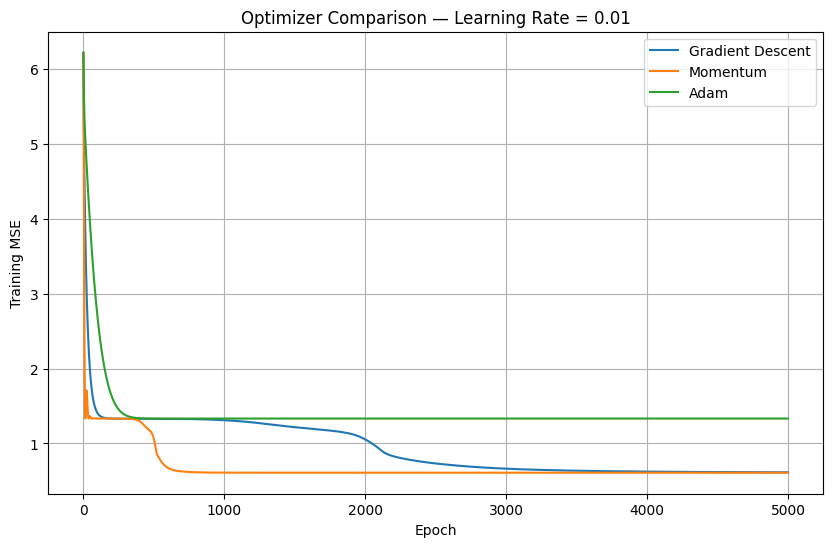

In [88]:
plt.figure(figsize=(10, 6))

for name in optimizers:
    key = f"{name} | lr=0.01"

    plt.plot(
        trained_models[key]["history"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Optimizer Comparison — Learning Rate = 0.01")
plt.legend()
plt.grid(True)
plt.show()


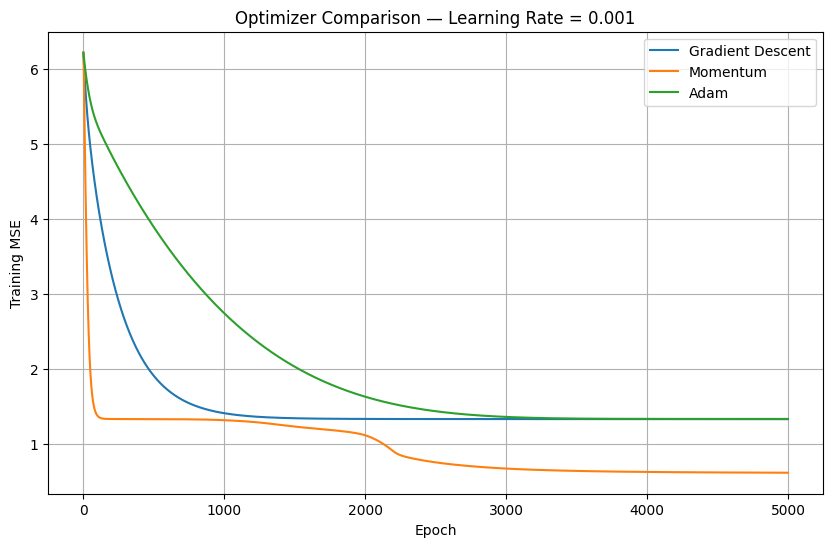

In [89]:
plt.figure(figsize=(10, 6))

for name in optimizers:
    key = f"{name} | lr=0.001"

    plt.plot(
        trained_models[key]["history"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Optimizer Comparison — Learning Rate = 0.001")
plt.legend()
plt.grid(True)
plt.show()


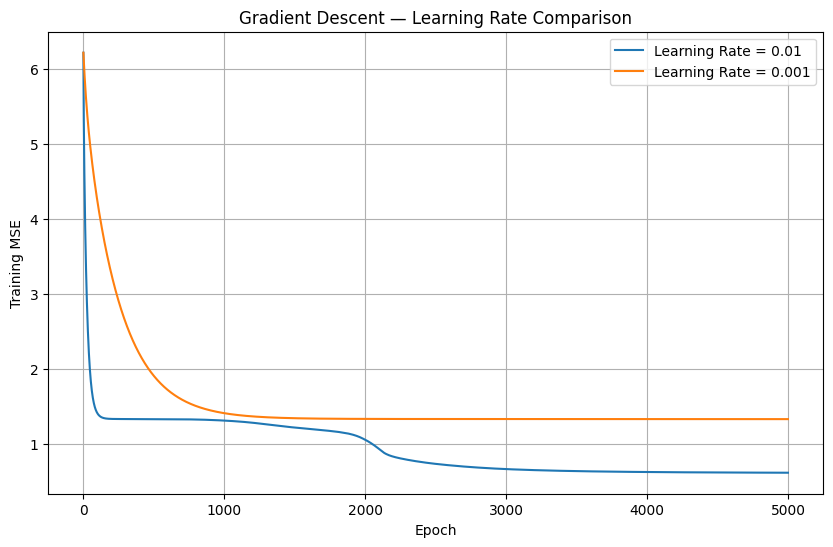

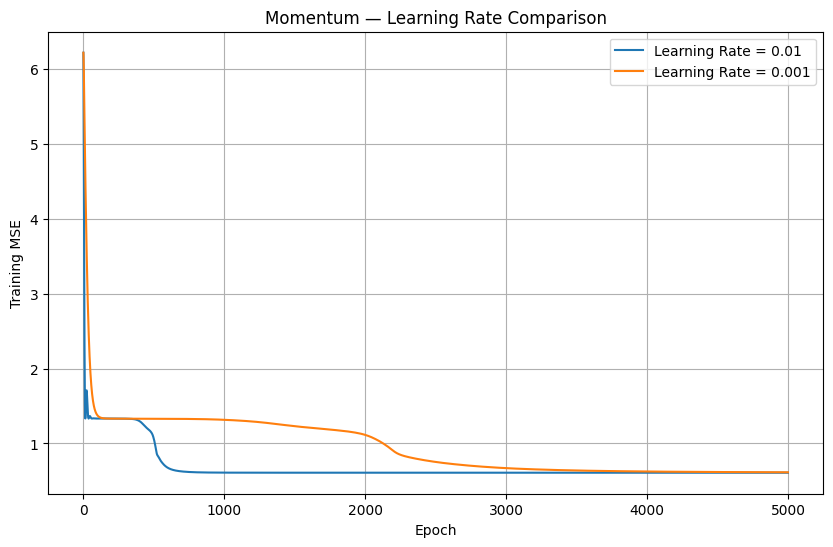

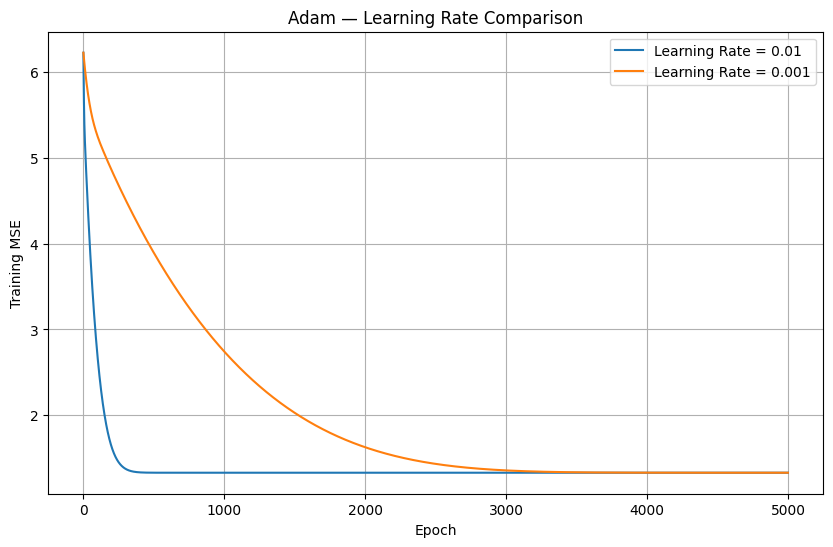

In [90]:
for name in optimizers:

    plt.figure(figsize=(10, 6))

    for lr in learning_rates:

        key = f"{name} | lr={lr}"

        plt.plot(
            trained_models[key]["history"],
            label=f"Learning Rate = {lr}"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Training MSE")
    plt.title(f"{name} — Learning Rate Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()


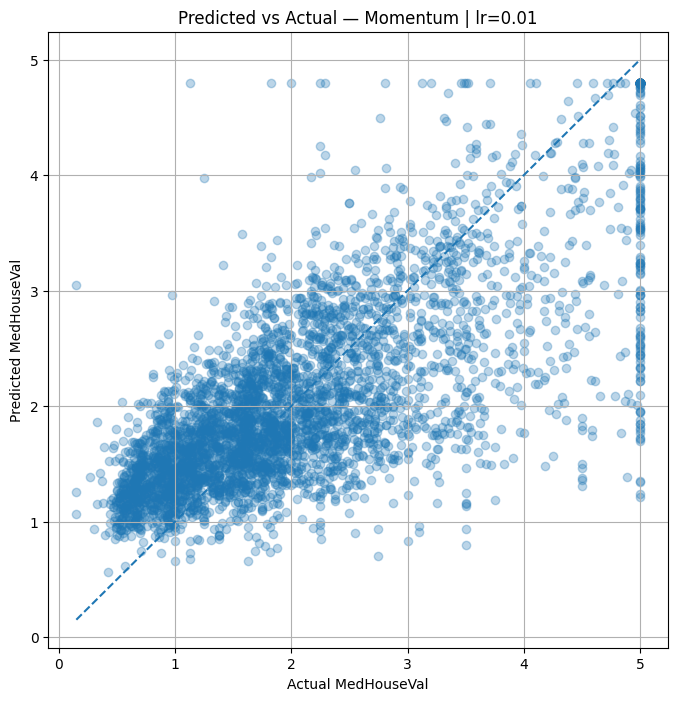

Best configuration: Momentum | lr=0.01
Test MSE: 0.6088729673539259
Test RMSE: 0.780303125300627


In [91]:
best = results_df.iloc[0]

best_key = (
    f"{best['Optimizer']} | "
    f"lr={best['Learning Rate']}"
)

best_predictions = trained_models[
    best_key
]["predictions"]

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.3
)

low = min(y_test.min(), best_predictions.min())
high = max(y_test.max(), best_predictions.max())

plt.plot(
    [low, high],
    [low, high],
    linestyle="--"
)

plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title(f"Predicted vs Actual — {best_key}")
plt.grid(True)
plt.show()

print("Best configuration:", best_key)
print("Test MSE:", best["Test MSE"])
print("Test RMSE:", best["Test RMSE"])


# Bonus 1: Third Hidden Layer

Compare the required architecture:

2 → 5 → 3 → 1

with:

2 → 5 → 3 → 2 → 1


In [92]:
bonus_architecture = [2, 5, 3, 2, 1]

bonus_results = []
bonus_models = {}

for name, optimizer_code in optimizers.items():

    for lr in learning_rates:

        print(f"Bonus: {name}, learning rate = {lr}")

        model, history, elapsed = train_network(
            bonus_architecture,
            X_train_norm,
            y_train,
            optimizer=optimizer_code,
            lr=lr,
            epochs=epochs,
            l2=0.0,
            seed=10
        )

        test_mse, test_rmse, predictions = evaluate_model(
            model,
            X_test_norm,
            y_test
        )

        bonus_results.append({
            "Optimizer": name,
            "Learning Rate": lr,
            "Final Training Loss": history[-1],
            "Test MSE": test_mse,
            "Test RMSE": test_rmse,
            "Training Time (seconds)": elapsed,
            "Epochs": len(history)
        })

        key = f"{name} | lr={lr}"

        bonus_models[key] = {
            "model": model,
            "history": history,
            "predictions": predictions
        }

bonus_df = pd.DataFrame(bonus_results).sort_values(
    "Test MSE"
).reset_index(drop=True)

bonus_df


Bonus: Gradient Descent, learning rate = 0.01
Bonus: Gradient Descent, learning rate = 0.001
Bonus: Momentum, learning rate = 0.01
Bonus: Momentum, learning rate = 0.001
Bonus: Adam, learning rate = 0.01
Bonus: Adam, learning rate = 0.001


,Optimizer,Learning Rate,Final Training Loss,Test MSE,Test RMSE,Training Time (seconds),Epochs
0,Momentum,0.010,0.604960,0.604961,0.777793,20.985322,5000
1,Adam,0.001,0.606597,0.607419,0.779371,21.894361,5000
2,Gradient Descent,0.010,0.621940,0.621257,0.788198,21.277971,5000
3,Gradient Descent,0.001,1.311595,1.301765,1.140949,19.940159,5000
4,Momentum,0.001,1.332633,1.327222,1.152051,20.079673,5000
5,Adam,0.010,1.332632,1.327231,1.152055,21.912400,5000


In [93]:
required_best = results_df.iloc[0]
bonus_best = bonus_df.iloc[0]

pd.DataFrame([
    {
        "Architecture": "2 → 5 → 3 → 1",
        "Best Optimizer": required_best["Optimizer"],
        "Learning Rate": required_best["Learning Rate"],
        "Test MSE": required_best["Test MSE"],
        "Test RMSE": required_best["Test RMSE"]
    },
    {
        "Architecture": "2 → 5 → 3 → 2 → 1",
        "Best Optimizer": bonus_best["Optimizer"],
        "Learning Rate": bonus_best["Learning Rate"],
        "Test MSE": bonus_best["Test MSE"],
        "Test RMSE": bonus_best["Test RMSE"]
    }
])


,Architecture,Best Optimizer,Learning Rate,Test MSE,Test RMSE
0,2 → 5 → 3 → 1,Momentum,0.01,0.608873,0.780303
1,2 → 5 → 3 → 2 → 1,Momentum,0.01,0.604961,0.777793


# Bonus 2: L2 Regularization

L2 regularization: Using lambda = 0.001.


In [94]:
l2_lambda = 0.001

l2_results = []
l2_models = {}

for name, optimizer_code in optimizers.items():

    for lr in learning_rates:

        print(f"L2: {name}, learning rate = {lr}")

        model, history, elapsed = train_network(
            architecture,
            X_train_norm,
            y_train,
            optimizer=optimizer_code,
            lr=lr,
            epochs=epochs,
            l2=l2_lambda,
            seed=10
        )

        test_mse, test_rmse, predictions = evaluate_model(
            model,
            X_test_norm,
            y_test
        )

        l2_results.append({
            "Optimizer": name,
            "Learning Rate": lr,
            "L2 Lambda": l2_lambda,
            "Final Training Loss": history[-1],
            "Test MSE": test_mse,
            "Test RMSE": test_rmse,
            "Training Time (seconds)": elapsed,
            "Epochs": len(history)
        })

        key = f"{name} | lr={lr}"

        l2_models[key] = {
            "model": model,
            "history": history,
            "predictions": predictions
        }

l2_df = pd.DataFrame(l2_results).sort_values(
    "Test MSE"
).reset_index(drop=True)

l2_df


L2: Gradient Descent, learning rate = 0.01
L2: Gradient Descent, learning rate = 0.001
L2: Momentum, learning rate = 0.01
L2: Momentum, learning rate = 0.001
L2: Adam, learning rate = 0.01
L2: Adam, learning rate = 0.001


,Optimizer,Learning Rate,L2 Lambda,Final Training Loss,Test MSE,Test RMSE,Training Time (seconds),Epochs
0,Adam,0.001,0.001,0.610458,0.607028,0.779120,15.853108,5000
1,Momentum,0.010,0.001,0.612808,0.609130,0.780468,15.485651,5000
2,Adam,0.010,0.001,0.610632,0.609180,0.780500,16.740363,5000
3,Gradient Descent,0.010,0.001,0.619673,0.611823,0.782191,15.547237,5000
4,Momentum,0.001,0.001,0.620086,0.612113,0.782376,15.244863,5000
5,Gradient Descent,0.001,0.001,1.335374,1.323741,1.150539,15.567782,5000


## 16. L2 Regularization Comparison

In [95]:
regularization_rows = []

for _, row in results_df.iterrows():

    l2_row = l2_df[
        (l2_df["Optimizer"] == row["Optimizer"]) &
        (l2_df["Learning Rate"] == row["Learning Rate"])
    ].iloc[0]

    regularization_rows.append({
        "Configuration":
            f"{row['Optimizer']} | lr={row['Learning Rate']}",
        "MSE Without L2": row["Test MSE"],
        "MSE With L2": l2_row["Test MSE"],
        "RMSE Without L2": row["Test RMSE"],
        "RMSE With L2": l2_row["Test RMSE"]
    })

pd.DataFrame(regularization_rows)


,Configuration,MSE Without L2,MSE With L2,RMSE Without L2,RMSE With L2
0,Momentum | lr=0.01,0.608873,0.609130,0.780303,0.780468
1,Gradient Descent | lr=0.01,0.611663,0.611823,0.782089,0.782191
2,Momentum | lr=0.001,0.611906,0.612113,0.782244,0.782376
3,Gradient Descent | lr=0.001,1.323679,1.323741,1.150512,1.150539
4,Adam | lr=0.001,1.327218,0.607028,1.152050,0.779120
5,Adam | lr=0.01,1.327220,0.609180,1.152050,0.780500


In [96]:
results_df.to_csv(
    "task2_required_results.csv",
    index=False
)

bonus_df.to_csv(
    "task2_third_hidden_layer_results.csv",
    index=False
)

l2_df.to_csv(
    "task2_l2_results.csv",
    index=False
)

print("All result CSV files saved.")


All result CSV files saved.
